In [ ]:
!pip install pettingzoo[mpe] stable-baselines3 torch wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 33.9 MB/s eta 0:00:00


In [ ]:
!pip install supersuit -q
!pip install supersuit stable-baselines3 pettingzoo[mpe] -q
!pip install supersuit pettingzoo[mpe] gymnasium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 28.5 MB/s eta 0:00:00



Experiment: 1_ModelFree | Seed: 42


100%|██████████| 5000/5000 [03:40<00:00, 22.72it/s]



Experiment: 1_ModelFree | Seed: 123


100%|██████████| 5000/5000 [03:39<00:00, 22.79it/s]



Experiment: 1_ModelFree | Seed: 999


...

100%|██████████| 5000/5000 [08:11<00:00, 10.17it/s]



Experiment: 4_Hybrid_CGAWM | Seed: 123


100%|██████████| 5000/5000 [08:00<00:00, 10.40it/s]



Experiment: 4_Hybrid_CGAWM | Seed: 999


100%|██████████| 5000/5000 [06:32<00:00, 12.75it/s]


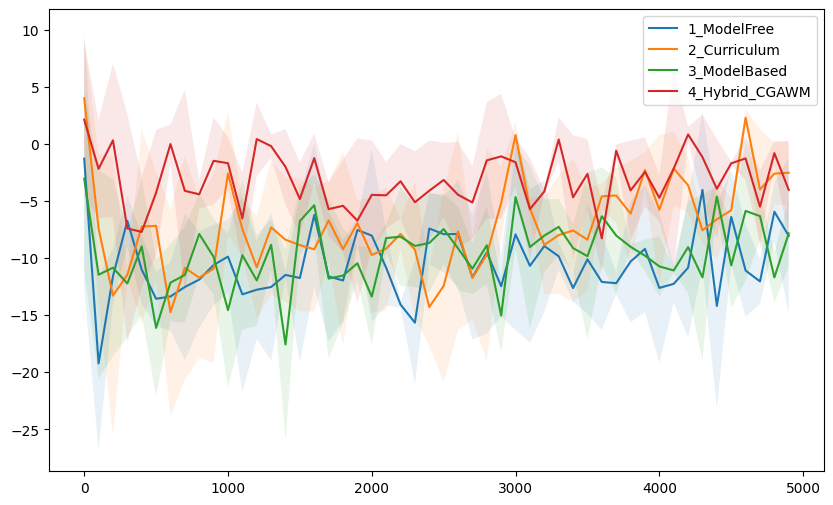

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np, random, collections, copy, datetime, json
import matplotlib.pyplot as plt
from pettingzoo.mpe import simple_adversary_v3
import gymnasium as gym
from tqdm import tqdm
import pandas as pd

# ---------- 1. CONFIGURATION ----------
THESIS_LOCK = {
    'env_id': 'simple_adversary_v3',
    'max_cycles': 50,
    'curriculum_stages': [1, 2, 3],
    'curriculum_threshold': -0.5,
    'curriculum_window': 50,
    'use_model': True,
    'num_ensemble_models': 5,
    'dynamics_weight_decay': 1e-4,
    'imagination_horizon': 1,
    'imagination_batch_size': 64,
    'model_data_ratio': 0.10,
    'imagination_frequency': 1,
    'eps_start': 1.0,
    'eps_decay': 0.9999,
    'eps_min': 0.3,
    'bonus_scale': 0.01,
    'bonus_clip': (-1.0, 1.0),
    'batch_size': 128,
    'real_cap': 50000,
    'model_cap': 50000,
    'gamma': 0.99,
    'tau': 0.005,
    'ent_coef': 0.5,
    'p_lr': 1e-4,
    'c_lr': 1e-4,
    'd_lr': 1e-4,
    'target_update_freq': 100,
    'eval_episodes': 20,
    'max_episodes': 5000,
    'eval_interval': 100,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# ---------- 2. ENVIRONMENT WRAPPER ----------
class FlatEnv(gym.Env):
    def __init__(self, num_adv=1):
        self.pz = simple_adversary_v3.parallel_env(N=num_adv, max_cycles=50, continuous_actions=False)
        self.pz.reset()
        self.ags = self.pz.possible_agents

        # Calculate total observation size (Sum of all agents)
        self.obs_sz = sum([self.pz.observation_space(a).shape[0] for a in self.ags])
        n_act = self.pz.action_space(self.ags[0]).n

        self.action_space = gym.spaces.MultiDiscrete([n_act] * len(self.ags))
        self.observation_space = gym.spaces.Box(-np.inf, np.inf, (self.obs_sz,), np.float32)
        self.last_d = 0

    def reset(self, seed=None):
        obs, info = self.pz.reset(seed=seed)
        self.last_d = self._d(obs)
        return self._flat(obs), info

    def step(self, acts):
        acts_dict = {a: int(acts[i]) for i, a in enumerate(self.ags)}
        obs, rew, term, trunc, info = self.pz.step(acts_dict)

        d = self._d(obs)
        dr = d - self.last_d
        self.last_d = d

        r = rew.get('agent_0', 0.0)
        # Terminal penalty vs distance-based reward
        r = -50.0 if (term.get('agent_0') or trunc.get('agent_0')) and r < 0 else (dr * 1.0 + 0.05)

        done = all(term.values()) or all(trunc.values())
        return self._flat(obs), r, done, False, info

    def _d(self, obs):
        lp = obs['agent_0'][:2]
        ap = [obs[a][:2] for a in obs if 'adversary' in a]
        return np.min(np.linalg.norm(np.array(ap) - lp, axis=1)) if ap else 0

    def _flat(self, obs):
        return np.concatenate([obs[a] for a in self.ags]).astype(np.float32)

    def close(self):
        self.pz.close()

class CurriculumManager:
    def __init__(self, stages, threshold=-0.5, window=50):
        self.stages = stages; self.th = threshold; self.win = window
        self.buf = collections.deque(maxlen=window); self.idx = 0
    def stage(self): return self.stages[self.idx]
    def update(self, r):
        self.buf.append(r)
        if len(self.buf) == self.win and np.mean(self.buf) >= self.th and self.idx < len(self.stages)-1:
            self.idx += 1; self.buf.clear(); return True
        return False

# ---------- 3. NETWORKS ----------
class Dyn(nn.Module):
    def __init__(self, s_dim, a_dim, h=256, n_acts_per=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + a_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, s_dim + 1 + n_acts_per)
        )
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class Critic(nn.Module):
    def __init__(self, s_dim, a_dim, h=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + a_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, 1)
        )
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class PolicyNet(nn.Module):
    def __init__(self, s_dim, n_acts, h=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, n_acts)
        )
    def forward(self, s): return self.net(s)

class Buf:
    def __init__(self, cap): self.b = collections.deque(maxlen=cap)
    def add(self, s, a, r, ns, d): self.b.append((s, a, r, ns, d))
    def sample(self, n):
        s, a, r, ns, d = zip(*random.sample(self.b, n))
        return torch.FloatTensor(np.array(s)).to(device), torch.LongTensor(np.array(a)).to(device), \
               torch.FloatTensor(r).unsqueeze(1).to(device), torch.FloatTensor(np.array(ns)).to(device), \
               torch.FloatTensor(d).unsqueeze(1).to(device)
    def __len__(self): return len(self.b)

# ---------- 4. AGENT ----------
class MAMBRLAgent:
    def __init__(self, s_dim, n_agents, n_acts, cfg):
        self.cfg = cfg; self.s_dim = s_dim; self.n_agents = n_agents; self.n_acts = n_acts
        self.a_dim = n_agents * n_acts
        self.off = torch.arange(n_agents) * n_acts
        self.real_buf = Buf(cfg['real_cap']); self.model_buf = Buf(cfg['model_cap'])
        self.steps = 0

        if cfg['use_model']:
            self.models = nn.ModuleList([Dyn(s_dim, self.a_dim, n_acts_per=n_acts).to(device) for _ in range(cfg['num_ensemble_models'])])
            self.opt_dyn = [optim.Adam(m.parameters(), lr=cfg['d_lr']) for m in self.models]
            self.critic = Critic(s_dim, self.a_dim).to(device)
        else:
            self.policy_net = PolicyNet(s_dim, n_acts).to(device)
            self.opt_pol = optim.Adam(self.policy_net.parameters(), lr=cfg['p_lr'])
            self.critic = Critic(s_dim, n_acts).to(device)

        self.tgt_critic = copy.deepcopy(self.critic)
        self.opt_cri = optim.Adam(self.critic.parameters(), lr=cfg['c_lr'])

    def act(self, s, explore=True):
        with torch.no_grad():
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            if self.cfg['use_model']:
                # Input must be (s_dim + a_dim)
                dummy_a = torch.zeros(1, self.a_dim, device=device)
                logits = self.models[0](s_t, dummy_a)[:, -self.n_acts:]
            else:
                logits = self.policy_net(s_t)

            probs = torch.softmax(torch.nan_to_num(logits, 0.0), -1)
            if explore and random.random() < self.cfg['eps_min']:
                a_lead = random.randrange(self.n_acts)
            else:
                a_lead = torch.argmax(probs).item()

        joint = np.zeros(self.n_agents, dtype=np.int32)
        joint[0] = a_lead # Leader acts, adversaries placeholder 0
        return joint

    def update_dyn(self):
        if not self.cfg['use_model'] or len(self.real_buf) < self.cfg['batch_size']: return 0
        s, a, r, ns, _ = self.real_buf.sample(self.cfg['batch_size'])
        aoh = torch.zeros(s.shape[0], self.a_dim, device=device).scatter_(1, (a + self.off.to(device)).long(), 1)
        loss = 0
        for m, opt in zip(self.models, self.opt_dyn):
            pred = m(s, aoh)
            l = (pred[:, :self.s_dim] - ns).pow(2).mean() + 10 * (pred[:, self.s_dim].unsqueeze(1) - r).pow(2).mean()
            opt.zero_grad(); l.backward(); opt.step(); loss += l.item()
        return loss / len(self.models)

    def imagine(self):
        if not self.cfg['use_model'] or len(self.real_buf) < self.cfg['batch_size']: return
        s, _, _, _, _ = self.real_buf.sample(self.cfg['imagination_batch_size'])
        a_idx = torch.zeros(s.shape[0], self.n_agents, dtype=torch.long, device=device)
        aoh = torch.zeros(s.shape[0], self.a_dim, device=device).scatter_(1, (a_idx + self.off.to(device)), 1)
        with torch.no_grad():
            preds = torch.stack([m(s, aoh) for m in self.models])
            mu = preds.mean(0)
            # Epistemic Uncertainty calculation
            unc = preds[:, :, :self.s_dim].var(0).mean(-1, keepdim=True)
            ns, rex = mu[:, :self.s_dim], mu[:, self.s_dim].unsqueeze(1)
            rew = rex + (torch.clamp(self.cfg['bonus_scale'] * unc, *self.cfg['bonus_clip']) if self.cfg['use_unc'] else 0)
        for i in range(s.shape[0]):
            self.model_buf.add(s[i].cpu().numpy(), a_idx[i].cpu().numpy(), rew[i].item(), ns[i].cpu().numpy(), 0.0)

    def update(self):
        b = self.cfg['batch_size']
        if len(self.real_buf) < b: return
        s, a, r, ns, d = self.real_buf.sample(b)

        a_in = a if self.cfg['use_model'] else a[:, :1]
        off_in = self.off.to(device) if self.cfg['use_model'] else torch.tensor([0], device=device)
        target_a_dim = self.a_dim if self.cfg['use_model'] else self.n_acts

        aoh = torch.zeros(b, target_a_dim, device=device).scatter_(1, (a_in + off_in).long(), 1)

        with torch.no_grad():
            if self.cfg['use_model']:
                nxt_logits = self.models[0](ns, torch.zeros(b, self.a_dim, device=device))[:, -self.n_acts:]
                nxt_a = torch.argmax(nxt_logits, -1, keepdim=True)
                nxt_joint = torch.zeros(b, self.n_agents, device=device).long()
                nxt_joint[:, 0] = nxt_a.squeeze()
                nxt_aoh = torch.zeros(b, self.a_dim, device=device).scatter_(1, nxt_joint + self.off.to(device), 1)
            else:
                nxt_a = torch.argmax(self.policy_net(ns), -1, keepdim=True)
                nxt_aoh = torch.zeros(b, self.n_acts, device=device).scatter_(1, nxt_a, 1)
            tgt = r + (1-d) * self.cfg['gamma'] * self.tgt_critic(ns, nxt_aoh)

        cur = self.critic(s, aoh)
        loss_c = (cur - tgt).pow(2).mean()
        self.opt_cri.zero_grad(); loss_c.backward(); self.opt_cri.step()

        if self.cfg['use_model']:
            pol_out = self.models[0](s, torch.zeros(b, self.a_dim, device=device))[:, -self.n_acts:]
            ent = -(torch.softmax(pol_out, -1) * torch.log(torch.softmax(pol_out, -1) + 1e-6)).sum(-1).mean()
            loss_p = -self.critic(s, aoh).mean() - self.cfg['ent_coef'] * ent
            self.opt_dyn[0].zero_grad(); loss_p.backward(); self.opt_dyn[0].step()
        else:
            pol_out = self.policy_net(s)
            ent = -(torch.softmax(pol_out, -1) * torch.log(torch.softmax(pol_out, -1) + 1e-6)).sum(-1).mean()
            loss_p = -self.critic(s, aoh).mean() - self.cfg['ent_coef'] * ent
            self.opt_pol.zero_grad(); loss_p.backward(); self.opt_pol.step()

        if self.steps % self.cfg['target_update_freq'] == 0:
            for t, s_net in zip(self.tgt_critic.parameters(), self.critic.parameters()):
                t.data.copy_(t.data * (1.0 - self.cfg['tau']) + s_net.data * self.cfg['tau'])

# ---------- 5. RUNNER ----------
def run_experiment(name, cfg, seeds=[42, 123, 999]):
    os.makedirs('/content/thesis_ablations', exist_ok=True)
    all_seed_logs = []

    for seed in seeds:
        print(f"\nExperiment: {name} | Seed: {seed}")
        set_seed(seed)
        curr = CurriculumManager(cfg['curriculum_stages']) if cfg.get('use_curriculum') else None

        env = FlatEnv(num_adv=curr.stage() if curr else 1)
        agent = MAMBRLAgent(env.obs_sz, len(env.ags), env.action_space.nvec[0], cfg)

        log = {'reward': [], 'ep': []}

        for ep in tqdm(range(cfg['max_episodes'])):
            o, _ = env.reset(); done = False; ep_r = 0
            while not done:
                a = agent.act(o); no, r, done, _, _ = env.step(a)
                agent.real_buf.add(o, a, r, no, done); o = no; agent.steps += 1
                if agent.steps > 1000 and agent.steps % 50 == 0:
                    agent.update_dyn()
                    if agent.steps % cfg['imagination_frequency'] == 0: agent.imagine()
                    agent.update()
                ep_r += r

            if curr and curr.update(ep_r):
                # RE-INITIALIZE ON CURRICULUM STEP
                env.close(); env = FlatEnv(num_adv=curr.stage())
                agent = MAMBRLAgent(env.obs_sz, len(env.ags), env.action_space.nvec[0], cfg)

            if ep % cfg['eval_interval'] == 0:
                ev_rs = []
                for _ in range(cfg['eval_episodes']):
                    eo, _ = env.reset(); edone = False; er = 0
                    while not edone:
                        eo, r, edone, _, _ = env.step(agent.act(eo, False)); er += r
                    ev_rs.append(er)
                log['reward'].append(np.mean(ev_rs))
                log['ep'].append(ep)

        env.close()
        all_seed_logs.append(log)
        torch.save(all_seed_logs, f'/content/thesis_ablations/{name}_raw.pt')

    return all_seed_logs

# ---------- EXECUTION ----------
ablations = {
    '1_ModelFree': {**THESIS_LOCK, 'use_model': False, 'use_curriculum': False, 'use_unc': False},
    '2_Curriculum': {**THESIS_LOCK, 'use_model': False, 'use_curriculum': True, 'use_unc': False},
    '3_ModelBased': {**THESIS_LOCK, 'use_model': True, 'use_curriculum': False, 'use_unc': False},
    '4_Hybrid_CGAWM': {**THESIS_LOCK, 'use_model': True, 'use_curriculum': True, 'use_unc': True},
}

final_results = {}
for name, cfg in ablations.items():
    final_results[name] = run_experiment(name, cfg)

# PLOTTING
plt.figure(figsize=(10, 6))
for name, logs in final_results.items():
    rewards = np.array([l['reward'] for l in logs])
    eps = logs[0]['ep']
    plt.plot(eps, rewards.mean(0), label=name)
    plt.fill_between(eps, rewards.mean(0)-rewards.std(0), rewards.mean(0)+rewards.std(0), alpha=0.1)
plt.legend(); plt.show()

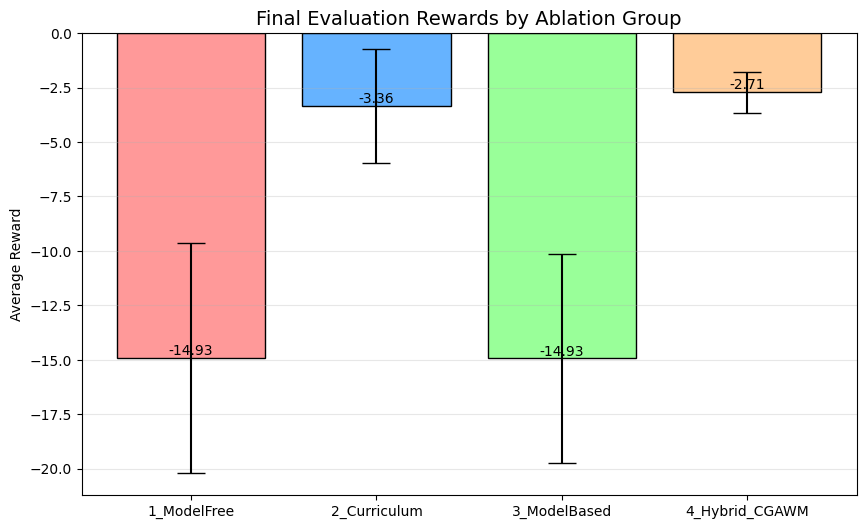

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

folder = '/content/thesis_ablations'
ablation_names = ['1_ModelFree', '2_Curriculum', '3_ModelBased', '4_Hybrid_CGAWM']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

means = []
stds = []

for name in ablation_names:
    path = f'{folder}/{name}_raw.pt'
    if os.path.exists(path):
        # FIXED: Added weights_only=False to bypass the new security default
        all_seed_logs = torch.load(path, weights_only=False)

        final_rewards = [log['reward'][-1] for log in all_seed_logs]
        means.append(np.mean(final_rewards))
        stds.append(np.std(final_rewards))
    else:
        print(f"Warning: File {path} not found.")
        means.append(0); stds.append(0)

# Create the Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(ablation_names, means, yerr=stds, capsize=10, color=colors, edgecolor='black')

plt.title('Final Evaluation Rewards by Ablation Group', fontsize=14)
plt.ylabel('Average Reward')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()